# Using and evaluating LLMs for social sciences

**Siyu Liang** · Department of Linguistics, Rice University

A language model is an **instrument**. This notebook administers it (ask a question, many times, under controlled conditions) and evaluates what comes back. Each section shows the **prompt**, every **raw answer**, and the **analysis**.

First move: **File → Save a copy in Drive**. Then run the cells in order (▶ or Shift+Enter).

To make it yours, change the text in CAPITALS: `QUESTION`, `CONDITIONS`, `PERSONAS`, `CODEBOOK`, and `N`.

## 0 · Setup

You need an Anthropic API key. In Colab, add it in the Secrets pane (🔑 on the left) under the name `ANTHROPIC_API_KEY` and switch on notebook access. Otherwise the cell asks you to type it (hidden).

In [1]:
import subprocess, sys
try:
    import anthropic
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "anthropic"], check=True)
    import anthropic

import os, re, math, statistics
from collections import Counter

key = os.environ.get("ANTHROPIC_API_KEY")
if not key:
    try:
        from google.colab import userdata
        key = userdata.get("ANTHROPIC_API_KEY")
    except Exception:
        pass
if not key:
    from getpass import getpass
    key = getpass("Anthropic API key: ")

MODEL = "claude-sonnet-5-5"   # the instrument; report it in your methods section
client = anthropic.Anthropic(api_key=key, max_retries=5)
print("ready:", MODEL)

ready: claude-sonnet-5-5


### The instrument

`ask(prompt)` sends one question to the model and returns its answer as text. Every call is independent: the model has no memory of earlier calls, so asking 10 times gives 10 fresh answers.

- `system` is the standing instruction (the interviewer script). The default just says it is a survey.
- `effort="low"` keeps the model's deliberation short. Survey answers are meant to be fast and intuitive; long deliberation can talk a model into a different answer. Report this setting.
- A refusal comes back as `[REFUSAL]`. It is a category of answer, not missing data.

In [2]:
SYSTEM = "You are answering a social-science survey. Answer the question as asked."

def ask(prompt, system=SYSTEM, max_tokens=1000, effort="low"):
    response = client.messages.create(
        model=MODEL, max_tokens=max_tokens, system=system,
        messages=[{"role": "user", "content": prompt}],
        output_config={"effort": effort},
    )
    if response.stop_reason == "refusal":
        return "[REFUSAL]"
    return "".join(b.text for b in response.content if b.type == "text").strip()

def first_number(text, lo, hi):
    '''The first integer within the scale found in the answer, or None.'''
    for m in re.findall(r"-?\d+", text):
        if lo <= int(m) <= hi:
            return int(m)
    return None

print(ask("Say hello in five words."))

Hello, it's nice to meet you.


### The toolkit

Every part below uses only these functions and its own settings cell, so you can edit one part without touching the others. Run this cell once.

- `run_many(question, n, scale)`: ask n times; print the prompt, the raw answers, and a tally
- `run_population(question, scale, population)`: ask once for 100 imagined people
- `compare(results, scale)`: distributions, means, entropy, Wasserstein
- `plot(dists, scale)`: bar chart of the distributions

In [3]:
def run_many(question, n, scale, system=SYSTEM, show=True):
    '''Ask n times, one answer each. Prints prompt, raw answers, tally. Returns parsed numbers.'''
    lo, hi = scale
    prompt = question + "\nAnswer with a single number."
    answers = [ask(prompt, system=system) for _ in range(n)]
    numbers = [first_number(a, lo, hi) for a in answers]
    if show:
        print("PROMPT\n" + prompt + "\n\nRAW ANSWERS")
        for a, v in zip(answers, numbers):
            short = a if len(a) <= 90 else a[:90] + "…"
            print(f"  {short!r}  ->  {v}")
        valid = [v for v in numbers if v is not None]
        print("\nTALLY", dict(sorted(Counter(valid).items())), f"| failed to parse: {numbers.count(None)}")
        if valid:
            print(f"mean {statistics.mean(valid):.2f}   spread (sd) {statistics.pstdev(valid):.2f}")
    return numbers

def run_population(question, scale, population, show=True):
    '''Ask once for 100 imagined people. Prints prompt and tally. Returns the 100 numbers.'''
    lo, hi = scale
    prompt = (question + f"\nImagine 100 different {population} answering this question. "
              f"Write exactly 100 numbers ({lo}-{hi}), one per person, as a Python list of integers and nothing else.")
    answer = ask(prompt, system="You are helping a social scientist simulate survey responses.", max_tokens=1500)
    numbers = [int(x) for x in re.findall(r"\b\d+\b", answer) if lo <= int(x) <= hi]
    if show:
        print("PROMPT\n" + prompt + "\n\nRAW ANSWER (first 120 characters)\n  " + answer[:120].replace("\n", " ") + "…")
        print(f"\nTALLY ({len(numbers)} numbers)", dict(sorted(Counter(numbers).items())))
        if numbers:
            print(f"mean {statistics.mean(numbers):.2f}   spread (sd) {statistics.pstdev(numbers):.2f}")
    return numbers

def distribution(numbers, scale):
    lo, hi = scale
    valid = [v for v in numbers if v is not None]
    return [valid.count(k) / len(valid) for k in range(lo, hi + 1)] if valid else None

def wasserstein(p, q):
    cp = cq = total = 0.0
    for a, b in zip(p, q):
        cp += a; cq += b; total += abs(cp - cq)
    return total

def entropy(p):
    return max(0.0, -sum(x * math.log2(x) for x in p if x > 0))

def compare(results, scale, title=""):
    lo, hi = scale
    names = list(results)
    dists = {n: distribution(results[n], scale) for n in names}
    means = {n: statistics.mean([v for v in results[n] if v is not None]) for n in names}
    print(title)
    print(f"{'':14s}" + "".join(f"{k:>6d}" for k in range(lo, hi + 1)) + "    mean  entropy")
    for n in names:
        print(f"{n:14s}" + "".join(f"{x:6.2f}" for x in dists[n]) + f"  {means[n]:6.2f}  {entropy(dists[n]):5.2f}")
    a, b = names[:2]
    print(f"{a} vs {b}: mean difference {means[a] - means[b]:+.2f}, "
          f"Wasserstein {wasserstein(dists[a], dists[b]):.2f} scale points\n")
    return dists

import matplotlib.pyplot as plt

def plot(dists, scale, title=""):
    lo, hi = scale
    xs = list(range(lo, hi + 1))
    colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
    w = 0.8 / len(dists)
    fig, ax = plt.subplots(figsize=(7, 3))
    for i, (name, p) in enumerate(dists.items()):
        ax.bar([x + (i - (len(dists) - 1) / 2) * w for x in xs], p, width=w * 0.9,
               color=colors[i], label=name, linewidth=0)
    ax.set_xticks(xs); ax.set_ylim(0, 1); ax.set_xlabel("answer"); ax.set_ylabel("share")
    ax.set_title(title, loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e6e6e3"); ax.set_axisbelow(True)
    ax.legend(frameon=False); plt.show()

print("toolkit ready")

toolkit ready


## 1 · One question, two ways of asking

A closed survey item, asked two ways:

1. **Ask `N` times.** Each call is independent, so this is the model's own answer distribution. Often it is the same answer every time: the model is *stable*, which says nothing about whether it is *right*.
2. **Ask once for 100 imagined people.** The model writes a list of 100 answers. This is the model's *belief about a population's distribution*, produced in one call. It is cheap and it has spread by construction.

These are **different objects**, and a paper must say which one it measured. Change `QUESTION`; keep the scale line, and leave the format sentences to the two helpers.

*This part needs only section 0 and its own settings cell.*

In [4]:
QUESTION = '''Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.'''
SCALE = (1, 5)
N = 10
POPULATION = "adults in the United States"     # who the 100 imagined respondents are

In [5]:
print("--- way 1: ask", N, "times ---")
many_1 = run_many(QUESTION, N, SCALE)
print("\n--- way 2: ask once for 100 imagined", POPULATION, "---")
pop_1 = run_population(QUESTION, SCALE, POPULATION)

--- way 1: ask 10 times ---


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Answer with a single number.

RAW ANSWERS
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3

TALLY {3: 10} | failed to parse: 0
mean 3.00   spread (sd) 0.00

--- way 2: ask once for 100 imagined adults in the United States ---


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Imagine 100 different adults in the United States answering this question. Write exactly 100 numbers (1-5), one per person, as a Python list of integers and nothing else.

RAW ANSWER (first 120 characters)
  [1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,4,4…

TALLY (100 numbers) {1: 10, 2: 19, 3: 28, 4: 23, 5: 20}
mean 3.24   spread (sd) 1.25


**What to notice.** Way 1 usually gives the same answer every time; the model's own view is stable, and a single answer would not have misled you about *the model*. Way 2 spreads out, because the model knows that populations disagree. Neither is a survey of anyone. Way 2 is what you would compare to a real poll; way 1 is what you would compare across prompts.

## 2 · Change one thing

The experiment: two prompts that differ in **exactly one thing**, everything else identical. Here the one thing is a single word, and the finding is decades old: Americans say the government spends too much on *welfare* and too little on *assistance to the poor* (Rasinski 1989). Does the model reproduce it?

Change `CONDITIONS`: wording, option order, a name, a persona, the language of the prompt. Keep the number of conditions small and the scale the same across them.

*This part needs only section 0 and its own settings cell. If a change here breaks something, put the original values back in the settings cell and re-run it.*

In [6]:
# settings for part 2 only; nothing here depends on part 1
POPULATION = "adults in the United States"
CONDITIONS = {
    "welfare": '''Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.''',

    "assistance": '''Do you think the government spends too little, about right, or too much on assistance to the poor?
1 = far too little, 3 = about right, 5 = far too much.''',
}
SCALE = (1, 5)
N = 10

In [7]:
single = {}
population = {}
for name, question in CONDITIONS.items():
    print(f"===== condition: {name} | way 1: ask {N} times =====")
    single[name] = run_many(question, N, SCALE)
    print(f"\n===== condition: {name} | way 2: 100 imagined {POPULATION} =====")
    population[name] = run_population(question, SCALE, POPULATION)
    print()

===== condition: welfare | way 1: ask 10 times =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Answer with a single number.

RAW ANSWERS
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '**3**'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3

TALLY {3: 10} | failed to parse: 0
mean 3.00   spread (sd) 0.00

===== condition: welfare | way 2: 100 imagined adults in the United States =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Imagine 100 different adults in the United States answering this question. Write exactly 100 numbers (1-5), one per person, as a Python list of integers and nothing else.

RAW ANSWER (first 120 characters)
  [1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,4…

TALLY (98 numbers) {1: 10, 2: 20, 3: 28, 4: 20, 5: 20}
mean 3.20   spread (sd) 1.26

===== condition: assistance | way 1: ask 10 times =====


PROMPT
Do you think the government spends too little, about right, or too much on assistance to the poor?
1 = far too little, 3 = about right, 5 = far too much.
Answer with a single number.

RAW ANSWERS
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2

TALLY {2: 10} | failed to parse: 0
mean 2.00   spread (sd) 0.00

===== condition: assistance | way 2: 100 imagined adults in the United States =====


PROMPT
Do you think the government spends too little, about right, or too much on assistance to the poor?
1 = far too little, 3 = about right, 5 = far too much.
Imagine 100 different adults in the United States answering this question. Write exactly 100 numbers (1-5), one per person, as a Python list of integers and nothing else.

RAW ANSWER (first 120 characters)
  [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3…

TALLY (104 numbers) {1: 15, 2: 24, 3: 29, 4: 17, 5: 19}
mean 3.01   spread (sd) 1.30



### Compare the conditions

Means hide shape, so compare whole distributions:

- **mean difference**: easy to read; two very different distributions can share a mean.
- **Wasserstein distance**: how far answers would have to move, in scale points, to turn one distribution into the other. The right default for an ordered scale.
- **entropy**: how spread out one condition's answers are (0 = always the same answer). Stability, checked before you trust a difference.

WAY 1: the model's own answers
                   1     2     3     4     5    mean  entropy
welfare         0.00  0.00  1.00  0.00  0.00    3.00   0.00
assistance      0.00  1.00  0.00  0.00  0.00    2.00   0.00
welfare vs assistance: mean difference +1.00, Wasserstein 1.00 scale points

WAY 2: 100 imagined adults in the United States
                   1     2     3     4     5    mean  entropy
welfare         0.10  0.20  0.29  0.20  0.20    3.20   2.26
assistance      0.14  0.23  0.28  0.16  0.18    3.01   2.28
welfare vs assistance: mean difference +0.19, Wasserstein 0.19 scale points



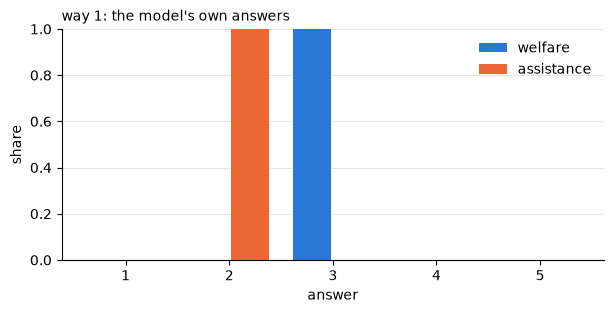

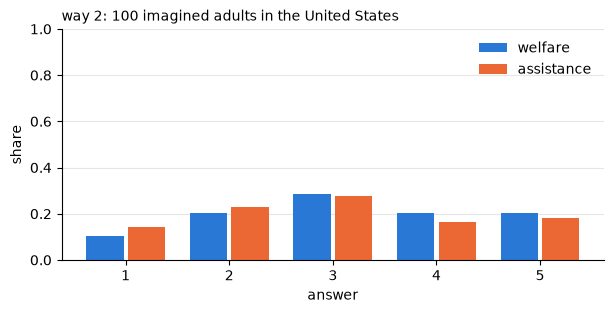

In [8]:
dists_single = compare(single, SCALE, "WAY 1: the model's own answers")
dists_population = compare(population, SCALE, "WAY 2: 100 imagined " + POPULATION)
plot(dists_single, SCALE, "way 1: the model's own answers")
plot(dists_population, SCALE, "way 2: 100 imagined " + POPULATION)

**Read the raw answers, not just the table.** Did one condition answer with a bare number and the other with a paragraph of caveats first? That is a difference in how the instrument treated the two prompts, and it is invisible in the mean.

**What did you measure?** A fact about the instrument: how this model, with these prompts, moves when one word changes. Whether the *size* of the shift matches people is a separate question, and it needs a baseline, such as the General Social Survey, which has carried both versions of this item for decades.

**Other things to try** (edit `CONDITIONS`; the helpers do the rest):

- **option order**: the same menu, reversed. On this model the single answers tend to start with "I'm an AI, so I don't worry…", which is a finding about the respondent.
- **a persona in the prompt**: "You are a 33-year-old nurse in Texas…" vs "You are 29 and have been unemployed for a year…"; set `POPULATION` to match for way 2.
- **matched guise**: the same sentence in two varieties of English, and a question about the *writer* (Hofmann et al. 2024). Expect refusals in prose rather than numbers that differ; the refusal pattern is the result.

## 3 · Open-ended answers, and the model as coder

Closed questions are easy to score and throw away the one thing a language model is best at: language. The price of open answers is **coding** them into categories.

Below: one open question, two personas, `N` answers each. Then the model codes every answer using a small codebook. **The model is now both the respondent and the coder.** Keep the two roles in separate prompts, and check the coder against yourself before trusting it.

Change `OPEN_QUESTION`, `PERSONAS`, and `CODEBOOK`.

*This part needs only section 0 and its own settings cell; it does not use anything from parts 1 or 2.*

In [9]:
# settings for part 3 only
OPEN_QUESTION = "In one sentence: what is the most important problem facing the country today?"

PERSONAS = {
    "retired teacher, Ohio":   "You are a 62-year-old retired teacher living in a small town in Ohio. Answer in your own voice.",
    "grad student, Houston":   "You are a 24-year-old graduate student living in Houston, Texas. Answer in your own voice.",
}

CODEBOOK = {
    "ECON":  "economy, prices, cost of living, jobs, taxes, housing",
    "POLIT": "the political system, polarization, democracy, corruption, politicians",
    "SOC":   "social policy: health care, education, immigration, inequality, crime",
    "ENV":   "environment and climate",
    "OTHER": "anything else, including don't know and refusals",
}
N_OPEN = 6

In [10]:
open_answers = {}
for name, persona in PERSONAS.items():
    print(f"===== {name} =====")
    open_answers[name] = [ask(OPEN_QUESTION, system=persona, max_tokens=2000) for _ in range(N_OPEN)]
    for a in open_answers[name]:
        print("  -", a)
    print()

===== retired teacher, Ohio =====


  - Honestly, I think it's that we've stopped listening to each other: neighbors who used to disagree over coffee now see each other as enemies, and until we can talk across that divide, we won't solve anything else, whether it's the economy, schools, or healthcare.
  - Honestly, I think it's that we've stopped being able to talk with our neighbors across political lines, because when people can't listen to each other, nothing else, whether it's the economy, schools, or healthcare, ever gets fixed.
  - Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines, because when we can't listen to each other, we can't solve anything else, whether it's the cost of groceries, our schools, or the health of our small towns.
  - Honestly, I think it's that we've stopped being able to talk to our neighbors who see things differently, because when people can't listen to each other, nothing else, whether it's the economy, schools, or healthcare, ever gets f

  - Honestly, it's the cost of living: between rent, groceries, health care, and student loans, it feels like even people with good education and steady work are struggling to build a stable life, and that squeeze is making everything else, from politics to mental health, worse.
  - Honestly, I think it's that we've lost the ability to agree on basic facts or talk to each other across political lines, which makes it nearly impossible to make progress on everything else, from housing costs and healthcare to climate and the economy.
  - Honestly, I think it's how expensive everything has gotten, especially housing, healthcare, and student debt, so that even people with degrees and steady work feel like they can't get ahead.
  - Honestly, I think it's that we've become so polarized and distrustful of each other that we can't agree on basic facts, which makes it nearly impossible to actually solve anything else, whether that's housing costs, health care, or climate stuff that hits us hard 

In [11]:
def code_answer(answer):
    '''The model as coder: the codebook goes in the prompt, one code comes out.'''
    book = "\n".join(f"{k}: {v}" for k, v in CODEBOOK.items())
    prompt = (f"Codebook:\n{book}\n\nRule: assign exactly one code, for the first topic mentioned. "
              f"Use no outside knowledge.\n\nResponse: \"{answer}\"\n\nAnswer with the code only.")
    out = ask(prompt, system="You are a trained content-analysis coder.").upper()
    return next((k for k in CODEBOOK if k in out), "OTHER")

codes = {}
for name, answers in open_answers.items():
    codes[name] = [code_answer(a) for a in answers]
    print(f"===== {name} =====")
    for c, a in zip(codes[name], answers):
        print(f"  {c:6s} {a[:100]}{'…' if len(a) > 100 else ''}")
    print("  distribution:", dict(Counter(codes[name])), "\n")

===== retired teacher, Ohio =====
  POLIT  Honestly, I think it's that we've stopped listening to each other: neighbors who used to disagree ov…
  POLIT  Honestly, I think it's that we've stopped being able to talk with our neighbors across political lin…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors who see things differe…
  POLIT  Honestly, I think it's that we've lost the ability to talk to our neighbors who see things different…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines…
  distribution: {'POLIT': 6} 



===== grad student, Houston =====
  ECON   Honestly, it's the cost of living: between rent, groceries, health care, and student loans, it feels…
  POLIT  Honestly, I think it's that we've lost the ability to agree on basic facts or talk to each other acr…
  ECON   Honestly, I think it's how expensive everything has gotten, especially housing, healthcare, and stud…
  POLIT  Honestly, I think it's that we've become so polarized and distrustful of each other that we can't ag…
  POLIT  Honestly, I think it's that we've lost the ability to agree on a shared set of facts and talk to eac…
  POLIT  Honestly, I think it's that we can't agree on basic facts or talk to each other across political lin…
  distribution: {'ECON': 2, 'POLIT': 4} 



**Check the coder.** Read the ten or so answers above and decide whether you would have given the same code. Where you disagree, is it the codebook (a category is vague) or the coder? In a real study you code a sample by hand, independently, and report agreement (Cohen's κ) before letting the model code the rest.

**Where is the baseline?** Nowhere, yet: two personas compared to each other tell you about the model's steerability, not about Ohio or Houston.

## 4 · Now you

Copy the block that matches your question and change the capitalized variables. Each part runs on its own after section 0, so breaking one does not break the others:

- **Part 1** if you want to know how the model answers one item, and how stable it is.
- **Part 2** if you want to vary one thing (wording, order, persona, language, a name) and compare.
- **Part 3** if your question needs answers in words.

Before you run, write down: what is the one thing you vary, what is held constant, and what you would need as a human baseline. After you run, write four sentences for a methods section: model and date, the exact prompts, `N` per condition, and the metric.

In [12]:
# your study here